In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [32]:

df = pd.read_csv("../Cleaned Data/msft_cleaned_dataset.csv", parse_dates=["Date"], index_col="Date")

data = df[["Close"]].copy()
print(data.head())

                 Close
Date                  
2021-01-04  210.002014
2021-01-05  210.204590
2021-01-06  204.754120
2021-01-07  210.580811
2021-01-08  211.863846


In [33]:
data["Prediction"] = data["Close"].shift(-1)  
data.dropna(inplace=True)  # Remove last row (no future value)
print(data.tail())

                 Close  Prediction
Date                              
2023-12-21  370.025513  371.055664
2023-12-22  371.055664  371.134949
2023-12-26  371.134949  370.550537
2023-12-27  370.550537  371.749115
2023-12-28  371.749115  372.501953


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Features (X) = Today's Close | Target (y) = Tomorrow's Close
X = data[["Close"]]
y = data["Prediction"]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
print("R² Score:", model.score(X_test, y_test))  # Closer to 1 = better

R² Score: 0.9410543064561744


In [35]:
# Predict
last_close = data["Close"].iloc[-1]
next_day_price = model.predict(pd.DataFrame([[last_close]], columns=X_train.columns))
print(f"Predicted next day close: ${next_day_price.item():.2f}")

Predicted next day close: $370.48


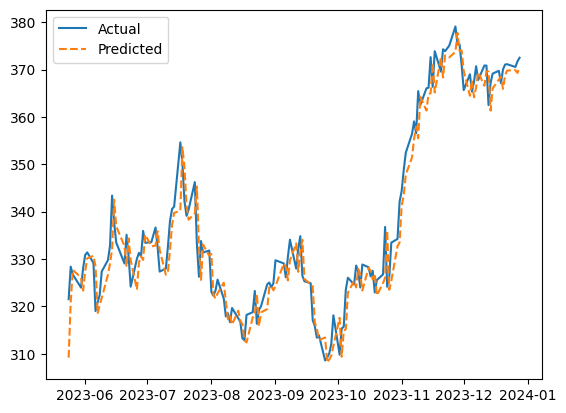

In [36]:
import matplotlib.pyplot as plt

# Get test predictions
predictions = model.predict(X_test)

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, predictions, label="Predicted", linestyle="--")
plt.legend()
plt.show()

In [53]:
# Multiple Stock Analysis 
stock_files = [
    "../Cleaned Data/apple_cleaned_dataset.csv", "../Cleaned Data/amazon_cleaned_dataset.csv",
    "../Cleaned Data/google_cleaned_dataset.csv", "../Cleaned Data/jpm_cleaned_dataset.csv",
    "../Cleaned Data/meta_cleaned_dataset.csv", "../Cleaned Data/msft_cleaned_dataset.csv",
    "../Cleaned Data/nvda_cleaned_dataset.csv", "../Cleaned Data/tesla_cleaned_dataset.csv",
    "../Cleaned Data/v_cleaned_dataset.csv", "../Cleaned Data/wmt_cleaned_dataset.csv"
]
# Load data to dict
stock_files_dict = {file.split("/")[-1].split("_")[0]: file for file in stock_files}
stock_models = {}
stock_predictions = {}
performance = {}

In [55]:
print(stock_files_dict)

{'apple': '../Cleaned Data/apple_cleaned_dataset.csv', 'amazon': '../Cleaned Data/amazon_cleaned_dataset.csv', 'google': '../Cleaned Data/google_cleaned_dataset.csv', 'jpm': '../Cleaned Data/jpm_cleaned_dataset.csv', 'meta': '../Cleaned Data/meta_cleaned_dataset.csv', 'msft': '../Cleaned Data/msft_cleaned_dataset.csv', 'nvda': '../Cleaned Data/nvda_cleaned_dataset.csv', 'tesla': '../Cleaned Data/tesla_cleaned_dataset.csv', 'v': '../Cleaned Data/v_cleaned_dataset.csv', 'wmt': '../Cleaned Data/wmt_cleaned_dataset.csv'}


In [38]:
# Model Training on the data
for stock_name, file_path in stock_files_dict.items():
    print(f"\nTraining model for {stock_name}...")
    
    # Load and prepare data
    df = pd.read_csv(file_path, parse_dates=["Date"], index_col="Date")
    

    df["MA_10"] = df["Close"].rolling(10).mean()
    df["MA_50"] = df["Close"].rolling(50).mean()
    df["Next_Close"] = df["Close"].shift(-1) 
    df.dropna(inplace=True)
    

    X = df[["Close", "MA_10", "MA_50"]]
    y = df["Next_Close"]
    
    # Train/Test Split (time-series aware)
    train_size = int(0.8 * len(X))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Model Training
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Store model and test data
    stock_models[stock_name] = model
    stock_predictions[stock_name] = (X_test, y_test)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    performance[stock_name] = {"MAE": mae, "R2": r2}
    
    print(f"Training complete! MAE: ${mae:.2f}, R²: {r2:.2f}")


Training model for apple...
Training complete! MAE: $1.70, R²: 0.93

Training model for amazon...
Training complete! MAE: $1.83, R²: 0.91

Training model for google...
Training complete! MAE: $1.55, R²: 0.88

Training model for jpm...
Training complete! MAE: $1.12, R²: 0.97

Training model for meta...
Training complete! MAE: $4.54, R²: 0.92

Training model for msft...
Training complete! MAE: $3.74, R²: 0.95

Training model for nvda...
Training complete! MAE: $0.81, R²: 0.86

Training model for tesla...
Training complete! MAE: $5.60, R²: 0.85

Training model for v...
Training complete! MAE: $1.93, R²: 0.94

Training model for wmt...
Training complete! MAE: $0.43, R²: 0.77


In [39]:
# Perfomace Analysis
print("\nModel Performance Comparison:")
performance_df = pd.DataFrame(performance).T.sort_values("R2", ascending=False)
print(performance_df)


Model Performance Comparison:
             MAE        R2
jpm     1.124590  0.965019
msft    3.737599  0.946319
v       1.929906  0.943695
apple   1.704525  0.926440
meta    4.537475  0.922471
amazon  1.833364  0.911586
google  1.549475  0.878821
nvda    0.813658  0.858444
tesla   5.597383  0.848364
wmt     0.431642  0.774472


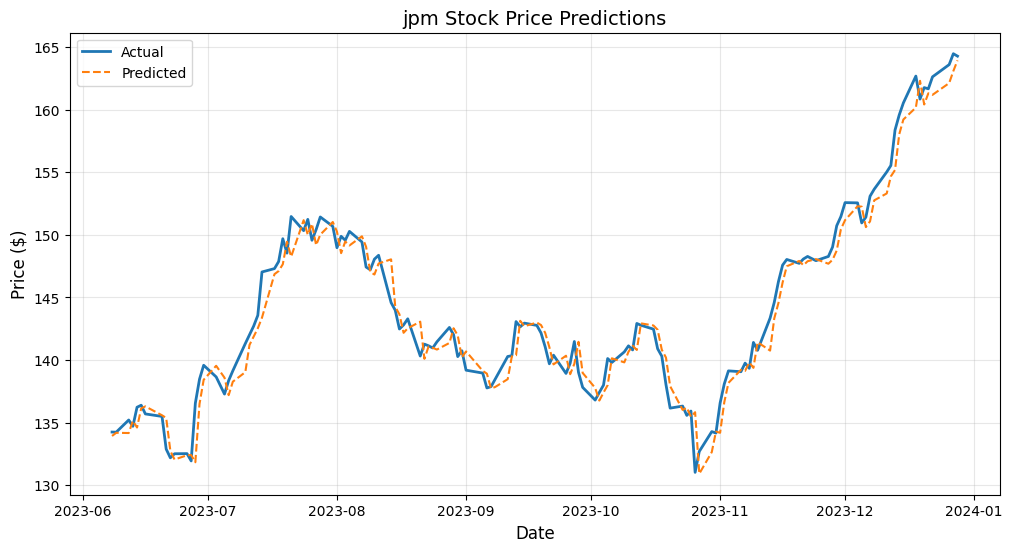

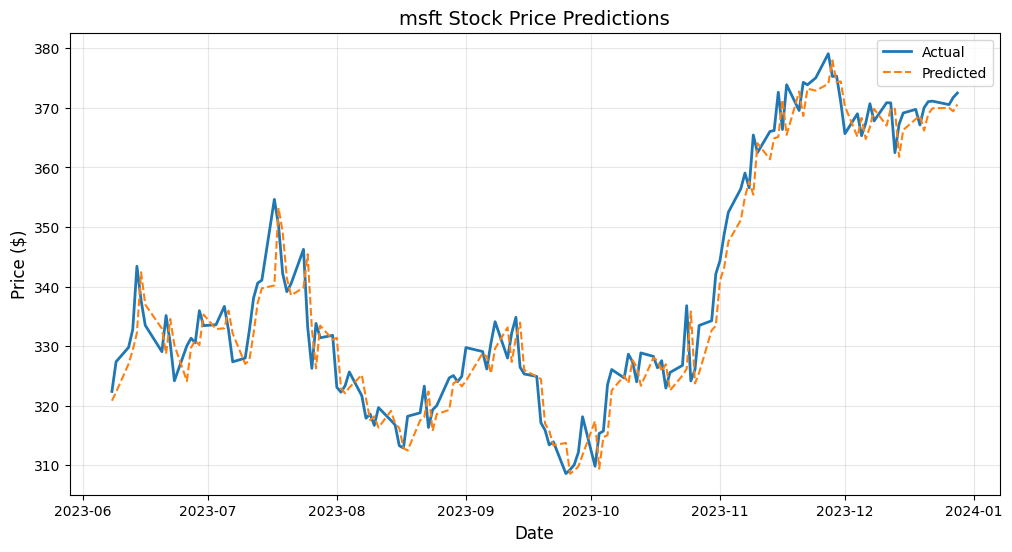

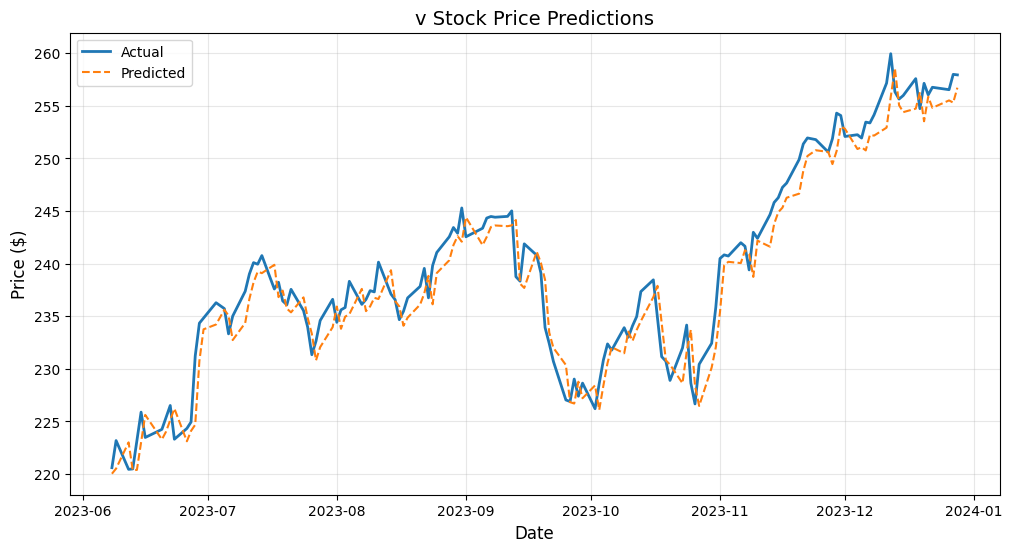

In [40]:
# Visulization
def plot_predictions(stock_name):
    model = stock_models[stock_name]
    X_test, y_test = stock_predictions[stock_name]
    y_pred = model.predict(X_test)
    
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label='Actual', linewidth=2)
    plt.plot(y_test.index, y_pred, label='Predicted', linestyle='--')
    plt.title(f"{stock_name} Stock Price Predictions", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price ($)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Example visualization for top 3 performing stocks
for stock_name in performance_df.index[:3]:
    plot_predictions(stock_name)

In [41]:
# Predication Function
def predict_next_day(stock_name):
    """Predict tomorrow's closing price for a given stock"""
    model = stock_models[stock_name]
    X_test, _ = stock_predictions[stock_name]
    last_data = X_test.iloc[-1:].values 
    
    prediction = model.predict(last_data)
    print(f"Predicted next day close for {stock_name}: ${prediction[0]:.2f}")
    return prediction[0]

def feature_importance(stock_name):
    """Shows important features  of a stock"""
    model = stock_models[stock_name]
    features = ["Current Close", "10-Day MA", "50-Day MA"]
    
    print(f"\nFeature Importance for {stock_name}:")
    for feature, coef in zip(features, model.coef_):
        print(f"{feature}: {coef:.4f}")

In [42]:
#Saving Models into Pre-Trained Models Folder
import os
save_dir = "../Pre-Trained Models"
print("\nSaving models...")
for stock_name, model in stock_models.items():
    model_path = os.path.join(save_dir, f"{stock_name}_model.pkl")
    joblib.dump(model, model_path)

print("All models saved to 'Pre-Trained Models' folder!")


Saving models...
All models saved to 'Pre-Trained Models' folder!


In [43]:
# Usage Example
if __name__ == "__main__":
    # Example predictions
    predict_next_day("apple")
    predict_next_day("tesla")
    
    # Example feature importance
    feature_importance("msft")
    feature_importance("nvda")

Predicted next day close for apple: $191.87
Predicted next day close for tesla: $253.16

Feature Importance for msft:
Current Close: 0.9551
10-Day MA: 0.0439
50-Day MA: -0.0125

Feature Importance for nvda:
Current Close: 0.9974
10-Day MA: 0.0084
50-Day MA: -0.0106


e:\Simple Stock Predication AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
e:\Simple Stock Predication AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
